In [1]:
# 퍼셉트론
# 입력 (x1, x2, x3 ...)
# 가중치 (w1, w2, w3 ...)
# 가중합 (w1*x1, w2*x2, w3*x3 ...)
# 활성화 함수 : 가중값이 임계값 이상이면 1 / 아니면 0
# 활성화 함수는 계단함수로 표현할 수 있음
# 퍼셉트론 학습 알고리즘 : 가중치와 임계값을 조정 / 퍼셉트론이 올바른 출력을 내도록 학습하는 알고리즘
# 퍼셉트론은 선형 분류기 / 선형적으로 구분 가능한 문제에 대해서만 올바른 출력 가능
# XOR 문제는 선형적으로 구분 불가능한 문제 -> 퍼셉트론으로 해결 불가

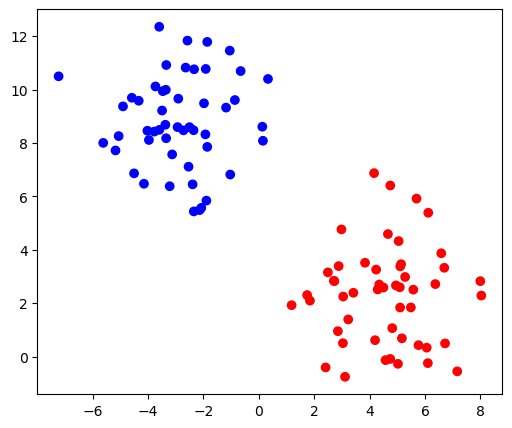

In [25]:
# 데이터 생성

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=100, 
    centers=2,
    random_state=42, 
    cluster_std=1.8
)

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.show()

In [36]:
# w1*x1 + w2*x2 + b = 0 -> 직선의 공식
import numpy as np

np.random.seed(150)
w = np.random.randn(2)
b = np.random.randn()

w, b

(array([-0.23138325,  0.39061323]), 0.35829746724517403)

In [2]:
# 수식을 변형
# w1*x1 + w2*x2 + b = 0  ->  y = ?
# w1*x + w2*y + b = 0
# w2*y = -(w1*x + b)
# y = -(w1*x + b) / w2

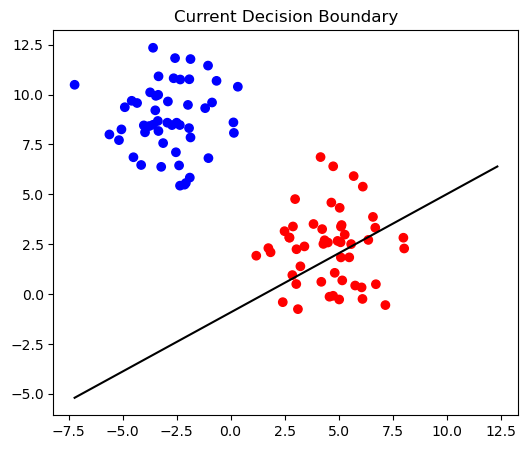

In [37]:
# 직선을 그리는 함수
def plot_line(w, b):
    x_vals = np.linspace(X[:,0].min(), X[:,1].max(), 100)
    y_vals = -(w[0]*x_vals + b) / w[1]
    _, ax = plt.subplots(figsize=(6,5))
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
    ax.plot(x_vals, y_vals, color='black')
    ax.set_title('Current Decision Boundary')
    plt.show()

plot_line(w, b)

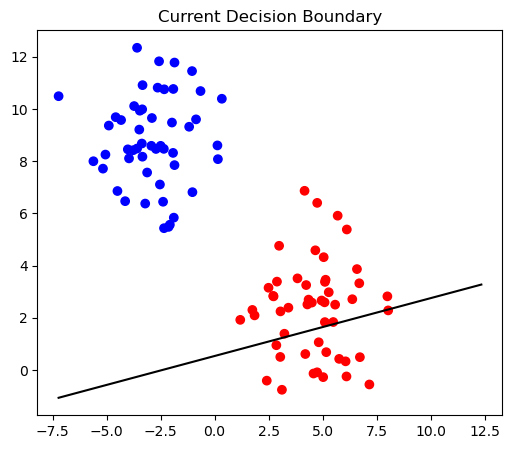

In [38]:
def preceptron_step(X, y, w, b, lr=0.1):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]
        yi = 1 if yi == 1 else -1
        pred = np.sign(np.dot(w, xi) + b)
        if pred != yi:
            w = w + lr * yi * xi
            b = b + lr*yi
            return w, b
    return w,b 
# 한번 업데이트
w,b = preceptron_step(X,y,w,b)
plot_line(w,b)

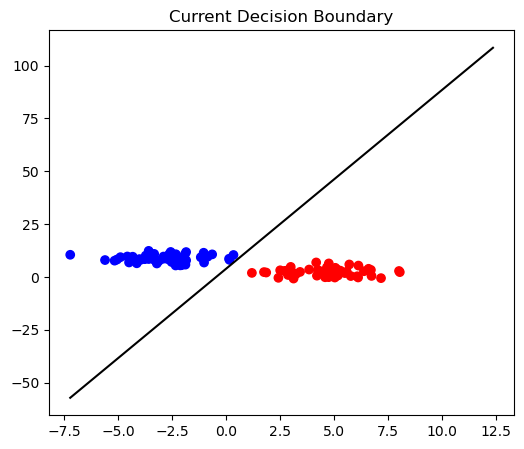

In [39]:
for i in range(100):
    w,b = preceptron_step(X,y,w,b)

plot_line(w, b)

In [44]:
# 퍼셉트론 라이브러리
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = (X.iloc[10].to_numpy()).reshape(-1,4)
print(per_clf.predict(X_new))
per_clf.score(X.to_numpy(), y)

[ True]


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


1.0

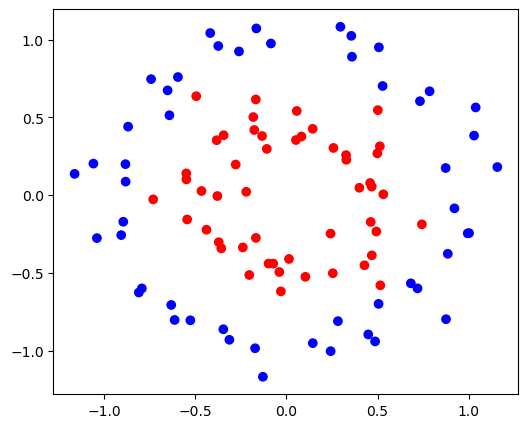

In [35]:
# 실패 사례
from sklearn.datasets import make_circles
X2, y2 = make_circles(
    n_samples=100,
    noise=0.1,
    factor=0.5,
    random_state=42
)
_, ax = plt.subplots(figsize=(6,5))
ax.scatter(X2[:,0], X2[:,1], c=y2, cmap='bwr')
plt.show()

In [40]:
# 다층 퍼셉트론 : 직선 여러개 생성 가능
# 입력층 -> 은닉층 -> 출력층
# 은닉층 뉴런하나 = 직선 하나

# 은닉층 = 퍼셉트론 하나
# z = w1*x1 + w2*x2 + b
# a = activation(z)  -> 활성화 함수 : 직선의 조합이 곡선이 되게 함

In [1]:
# 순전파

x = 2.0
w = 3.0
b = -1.0

def forward(x, w, b):
    return w * x + b

pred = forward(x, w , b)

y_true = [1.0, 0.0]
y_pred = [0.7, 0.2]
loss_items = []

# mse
for yt, yp in zip(y_true, y_pred):
    loss_items.append((yt - yp)**2)

mse = sum(loss_items) / len(loss_items)
print('pred', pred)
print('mse', mse)

pred 5.0
mse 0.06500000000000002


In [ ]:
# 학습률과 업데이트

w = 2.0
gradient = 0.5
lr = 0.1

def update_weight(w, gradient, lr):
    return w - lr * gradient
    
new_w = update_weight(w, gradient, lr)
new_w

In [ ]:
def predict_(x, w, b):
    value = np.dot(w, x) + b   # 연속적인 값 (실수)
    # 연속적인 값을 최종 변환 -> 양성(1) / 음성(-1) / 경계선(0)
    return np.sign(value)

def find_misclassified(x, y, b):
    for i in range(len(x)):
        xi = x[i]
        yi = 1 if y[i] == 1 else -1
        pred = predict_(xi, w, b)
        if pred != yi:
            return xi, yi
    return None, None

def update_(w, b, x, y, lr=0.1):
    w = w + lr*y*x
    b = b + lr*y
    return w, b
    